In [1]:
from pathlib import Path
import pyarrow.parquet as pq
import pandas as pd

current = Path.cwd()

for p in current.parents:
    candidate = p / "pipeline" / "output" / "clean_prices_50_assets.parquet"
    if candidate.exists():
        print("Found:", candidate)
        
        table = pq.read_table(candidate)
        prices = table.to_pandas(ignore_metadata=True)
        break
else:
    raise FileNotFoundError("Could not find clean_prices_50_assets.parquet")

print(prices.head())
print(prices.columns[:20])
print(prices.shape)

Found: /Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/clean_prices_50_assets.parquet
                     Date  ('Adj Close', 'AAPL')  ('Adj Close', 'AMD')  \
0 1970-01-01 00:26:17.923              72.400513             49.099998   
1 1970-01-01 00:26:18.009              71.696625             48.599998   
2 1970-01-01 00:26:18.268              72.267937             48.389999   
3 1970-01-01 00:26:18.355              71.928055             48.250000   
4 1970-01-01 00:26:18.441              73.085098             47.830002   

   ('Adj Close', 'AMZN')  ('Adj Close', 'ASML')  ('Adj Close', 'BABA')  \
0              94.900497             285.900818             208.714478   
1              93.748497             281.293610             206.083832   
2              95.143997             279.056122             205.741928   
3              95.343002             282.086700             206.682129   
4              94.598503             285.013458     

CONVERTING DATASET TO LONG

In [2]:
# The Date column is currently wrong because it was read as tiny timestamps around 1970.
# Convert it back using the numeric value inside the timestamp.

prices["Date"] = pd.to_datetime(prices["Date"])


date_num = (
    prices["Date"].dt.hour * 3600
    + prices["Date"].dt.minute * 60
    + prices["Date"].dt.second
    + prices["Date"].dt.microsecond / 1_000_000
)

print(date_num.head())
print(date_num.min(), date_num.max())

0    1577.923
1    1578.009
2    1578.268
3    1578.355
4    1578.441
Name: Date, dtype: float64
1577.923 1778.025


In [3]:
# Convert the bad 1970 timestamps back to real dates

bad_date = pd.to_datetime(prices["Date"])

# Convert 1970 timestamp back to seconds since epoch
seconds = (
    bad_date.dt.hour * 3600
    + bad_date.dt.minute * 60
    + bad_date.dt.second
    + bad_date.dt.microsecond / 1_000_000
)

# Your values are around 1577.923, so multiply by 1,000,000 to recover Unix seconds
prices["Date"] = pd.to_datetime(seconds * 1_000_000, unit="s").dt.normalize()

print(prices["Date"].head())
print(prices["Date"].tail())
print(prices["Date"].min(), prices["Date"].max())

0   2020-01-01
1   2020-01-02
2   2020-01-05
3   2020-01-06
4   2020-01-07
Name: Date, dtype: datetime64[ns]
1589   2026-04-29
1590   2026-04-30
1591   2026-05-03
1592   2026-05-04
1593   2026-05-05
Name: Date, dtype: datetime64[ns]
2020-01-01 00:00:00 2026-05-05 00:00:00


In [4]:
import ast

new_cols = []

for c in prices.columns:
    if c == "Date":
        new_cols.append(("Date", ""))
    elif isinstance(c, str) and c.startswith("("):
        new_cols.append(ast.literal_eval(c))
    else:
        new_cols.append(c)

prices.columns = pd.MultiIndex.from_tuples(new_cols)

print(prices.columns[:10])
print(prices.head())

MultiIndex([(     'Date',      ''),
            ('Adj Close',  'AAPL'),
            ('Adj Close',   'AMD'),
            ('Adj Close',  'AMZN'),
            ('Adj Close',  'ASML'),
            ('Adj Close',  'BABA'),
            ('Adj Close',   'BAC'),
            ('Adj Close', 'BRK-B'),
            ('Adj Close',   'COP'),
            ('Adj Close',  'COST')],
           )
        Date  Adj Close                                                \
                   AAPL        AMD       AMZN        ASML        BABA   
0 2020-01-01  72.400513  49.099998  94.900497  285.900818  208.714478   
1 2020-01-02  71.696625  48.599998  93.748497  281.293610  206.083832   
2 2020-01-05  72.267937  48.389999  95.143997  279.056122  205.741928   
3 2020-01-06  71.928055  48.250000  95.343002  282.086700  206.682129   
4 2020-01-07  73.085098  47.830002  94.598503  285.013458  207.033508   

                                                 ...  Volume            \
         BAC       BRK-B        COP     

In [5]:
date_col = prices[("Date", "")]

adj = prices.xs("Adj Close", level=0, axis=1).copy()
high = prices.xs("High", level=0, axis=1).copy()
low = prices.xs("Low", level=0, axis=1).copy()
volume = prices.xs("Volume", level=0, axis=1).copy()

adj["Date"] = date_col.values
high["Date"] = date_col.values
low["Date"] = date_col.values
volume["Date"] = date_col.values

adj_long = adj.melt(id_vars="Date", var_name="ticker", value_name="adj_close")
high_long = high.melt(id_vars="Date", var_name="ticker", value_name="high")
low_long = low.melt(id_vars="Date", var_name="ticker", value_name="low")
volume_long = volume.melt(id_vars="Date", var_name="ticker", value_name="volume")

df = (
    adj_long
    .merge(high_long, on=["Date", "ticker"])
    .merge(low_long, on=["Date", "ticker"])
    .merge(volume_long, on=["Date", "ticker"])
    .rename(columns={"Date": "date"})
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

print(df.head())
print(df.columns)

        date ticker  adj_close       high        low     volume
0 2020-01-01   AAPL  72.400513  75.150002  73.797501  135480400
1 2020-01-02   AAPL  71.696625  75.144997  74.125000  146322800
2 2020-01-05   AAPL  72.267937  74.989998  73.187500  118387200
3 2020-01-06   AAPL  71.928055  75.224998  74.370003  108872000
4 2020-01-07   AAPL  73.085098  76.110001  74.290001  132079200
Index(['date', 'ticker', 'adj_close', 'high', 'low', 'volume'], dtype='object')


In [6]:
df = (
    df[["date", "ticker", "adj_close", "high", "low", "volume"]]
    .drop_duplicates(["date", "ticker"])
    .sort_values(["ticker", "date"])
    .reset_index(drop=True)
)

print("df shape:", df.shape)
print("tickers:", df["ticker"].nunique())
print("date range:", df["date"].min(), df["date"].max())
print("duplicate date-ticker:", df.duplicated(["date", "ticker"]).sum())
print(df.head())

df shape: (67100, 6)
tickers: 50
date range: 2020-01-01 00:00:00 2026-05-05 00:00:00
duplicate date-ticker: 0
        date ticker  adj_close       high        low     volume
0 2020-01-01   AAPL  72.400513  75.150002  73.797501  135480400
1 2020-01-02   AAPL  71.696625  75.144997  74.125000  146322800
2 2020-01-05   AAPL  72.267937  74.989998  73.187500  118387200
3 2020-01-06   AAPL  71.928055  75.224998  74.370003  108872000
4 2020-01-07   AAPL  73.085098  76.110001  74.290001  132079200


RSI FEATURE

In [7]:
def compute_rsi(series, window = 14):
    delta = series.diff()

    gain = delta.clip(lower = 0)
    loss = -delta.clip(upper = 0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs= avg_gain/avg_loss
    rsi = 100-(100/1+rs)
    return rsi

TREND FEATURES

In [8]:
df["daily_return"] = df.groupby("ticker")["adj_close"].pct_change()
df["ma_20"] = df.groupby("ticker")["adj_close"].transform(lambda s: s.rolling(20).mean())
df["ma_50"] = df.groupby("ticker")["adj_close"].transform(lambda s: s.rolling(50).mean())
df["ma20_ma50_ratio"] = df["ma_20"] / df["ma_50"]
df["distance_to_ma20"] = (df["adj_close"] - df["ma_20"]) / df["ma_20"]
df["rolling_20d_return"] = df.groupby("ticker")["adj_close"].pct_change(20)



RSI

In [9]:
df["rsi_14"] = df.groupby("ticker")["adj_close"].transform(compute_rsi)

MACD

In [10]:
df["macd_12_26_9"] = df.groupby("ticker")["adj_close"].transform(
    lambda s: s.ewm(span=12, adjust=False).mean() - s.ewm(span=26, adjust=False).mean()
)
df["macd_signal"] = df.groupby("ticker")["macd_12_26_9"].transform(
    lambda s: s.ewm(span=9, adjust=False).mean()
)
df["macd_histogram"] = df["macd_12_26_9"] - df["macd_signal"]

VOLATILITY FEATURES

In [11]:
df["vol_20"] = df.groupby("ticker")["daily_return"].transform(lambda s: s.rolling(20).std())


ATR

In [12]:
prev_close = df.groupby("ticker")["adj_close"].shift(1)
tr1 = df["high"] - df["low"]
tr2 = (df["high"] - prev_close).abs()
tr3 = (df["low"] - prev_close).abs()
true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
df["atr_14"] = true_range.groupby(df["ticker"]).transform(lambda s: s.rolling(14).mean())

BOLLINGER

In [13]:
std20_price = df.groupby("ticker")["adj_close"].transform(lambda s: s.rolling(20).std())
upper = df["ma_20"] + 2 * std20_price
lower = df["ma_20"] - 2 * std20_price
df["bollinger_pct_b"] = (df["adj_close"] - lower) / (upper - lower)
df["bollinger_width"] = (upper - lower) / df["ma_20"]

VOLUME Z-SCORE

In [14]:
vol_mean_20 = df.groupby("ticker")["volume"].transform(lambda s: s.rolling(20).mean())
vol_std_20 = df.groupby("ticker")["volume"].transform(lambda s: s.rolling(20).std())
df["volume_zscore_20"] = (df["volume"] - vol_mean_20) / vol_std_20

FINALIZING AND QUALITY CHECKS

In [15]:
df = df.rename(columns={"daily_return": "return"})

In [16]:
final_cols = [
    "date",
    "ticker",
    "return",
    "ma_20",
    "ma_50",
    "ma20_ma50_ratio",
    "distance_to_ma20",
    "rolling_20d_return",
    "rsi_14",
    "macd_12_26_9",
    "macd_histogram",
    "vol_20",
    "atr_14",
    "bollinger_pct_b",
    "bollinger_width",
    "volume_zscore_20"
]

In [17]:
final_df = df[final_cols].dropna().copy()

In [18]:
final_df.head()

,date,ticker,return,ma_20,ma_50,ma20_ma50_ratio,distance_to_ma20,rolling_20d_return,rsi_14,macd_12_26_9,macd_histogram,vol_20,atr_14,bollinger_pct_b,bollinger_width,volume_zscore_20
49,2020-03-26,AAPL,-0.041402,64.505183,71.267747,0.905110,-0.072006,-0.169160,-0.700259,-3.802070,-0.246031,0.068909,5.368573,0.283828,0.333097,-1.397093
50,2020-03-29,AAPL,0.028538,64.103238,71.051111,0.902213,-0.039538,-0.115489,-0.654483,-3.536766,0.015418,0.069039,5.231203,0.379754,0.328814,-1.777633
51,2020-03-30,AAPL,-0.002041,63.639799,70.846040,0.898283,-0.034518,-0.131078,-0.723253,-3.298625,0.202848,0.068886,5.317736,0.391490,0.318114,-1.361083
52,2020-03-31,AAPL,-0.052617,63.245828,70.564883,0.896279,-0.079622,-0.119224,-0.782335,-3.332355,0.135294,0.068352,5.197047,0.256306,0.326728,-1.465636
53,2020-04-01,AAPL,0.016687,62.902357,70.309950,0.894644,-0.059154,-0.104002,-0.737182,-3.243321,0.179463,0.068508,4.988902,0.321040,0.330544,-1.495086


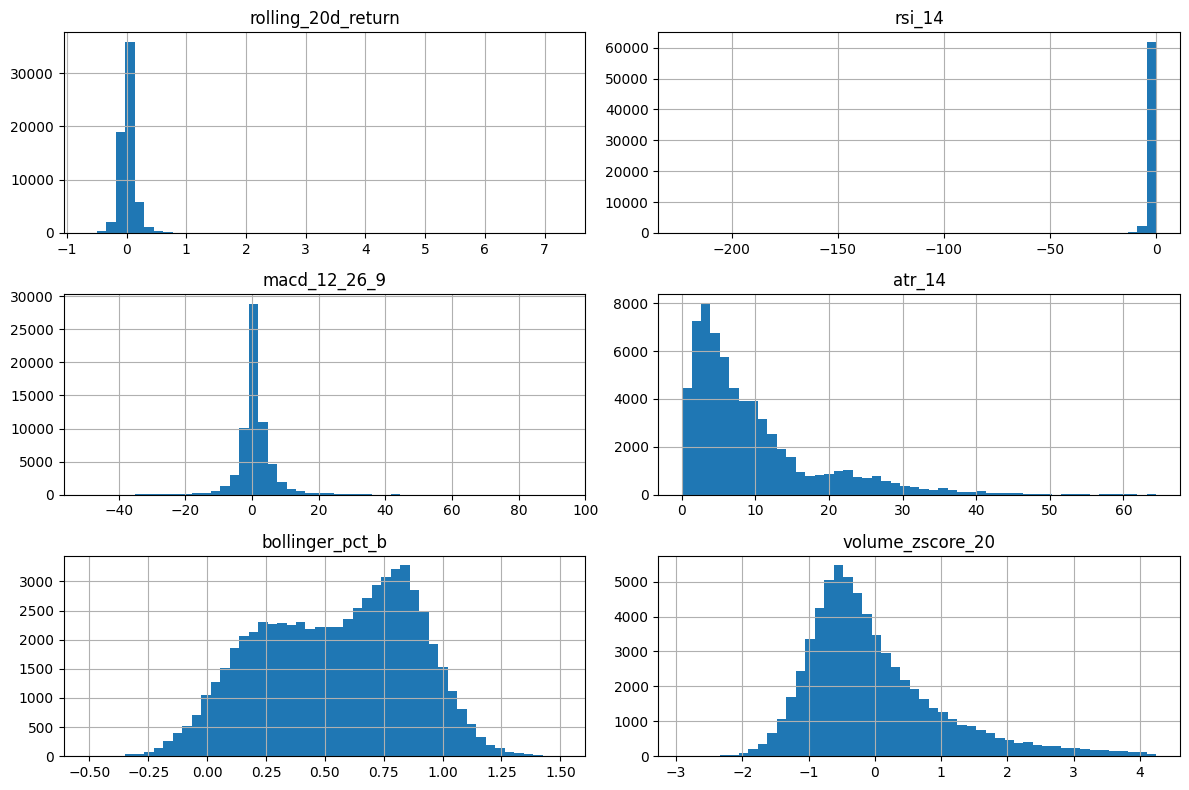

In [19]:
import matplotlib.pyplot as plt
import numpy as np

cols = [
    "rolling_20d_return",
    "rsi_14",
    "macd_12_26_9",
    "atr_14",
    "bollinger_pct_b",
    "volume_zscore_20"
]

# Filter out infinite values before plotting
for col in cols:
    # Replace inf and -inf with NaN
    final_df[col] = final_df[col].replace([np.inf, -np.inf], np.nan)


final_df[cols].hist(bins=50, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [19]:
final_df = final_df.dropna().copy()

In [20]:
print("final shape:", final_df.shape)
print("tickers:", final_df["ticker"].nunique())
print("date range:", final_df["date"].min(), final_df["date"].max())
print("duplicate date-ticker:", final_df.duplicated(["date", "ticker"]).sum())
print("total NaNs:", final_df.isna().sum().sum())
print(final_df.head())

final shape: (64650, 16)
tickers: 50
date range: 2020-03-26 00:00:00 2026-05-05 00:00:00
duplicate date-ticker: 0
total NaNs: 4
         date ticker    return      ma_20      ma_50  ma20_ma50_ratio  \
49 2020-03-26   AAPL -0.041402  64.505183  71.267747         0.905110   
50 2020-03-29   AAPL  0.028538  64.103238  71.051111         0.902213   
51 2020-03-30   AAPL -0.002041  63.639799  70.846040         0.898283   
52 2020-03-31   AAPL -0.052617  63.245828  70.564883         0.896279   
53 2020-04-01   AAPL  0.016687  62.902357  70.309950         0.894644   

    distance_to_ma20  rolling_20d_return    rsi_14  macd_12_26_9  \
49         -0.072006           -0.169160 -0.700259     -3.802070   
50         -0.039538           -0.115489 -0.654483     -3.536766   
51         -0.034518           -0.131078 -0.723253     -3.298625   
52         -0.079622           -0.119224 -0.782335     -3.332355   
53         -0.059154           -0.104002 -0.737182     -3.243321   

    macd_histogram    vo

In [21]:
df = df.sort_values(["ticker", "date"])

In [27]:
final_df.isna().sum()

date                  0
ticker                0
return                0
ma_20                 0
ma_50                 0
ma20_ma50_ratio       0
distance_to_ma20      0
rolling_20d_return    0
rsi_14                0
macd_12_26_9          0
macd_histogram        0
vol_20                0
atr_14                0
bollinger_pct_b       0
bollinger_width       0
volume_zscore_20      0
dtype: int64

In [28]:
final_df[cols].nunique()

rolling_20d_return    64546
rsi_14                64521
macd_12_26_9          64646
atr_14                64043
bollinger_pct_b       64646
volume_zscore_20      64631
dtype: int64

In [24]:
print(final_df["date"].min(), final_df["date"].max())

2020-03-26 00:00:00 2026-05-05 00:00:00


In [25]:
nan_rows = final_df[final_df["rsi_14"].isna()]
print(nan_rows[["date", "ticker", "return", "rsi_14"]])

            date ticker    return  rsi_14
8749  2023-04-18  BRK-B  0.002594     NaN
31946 2025-02-11   META  0.003345     NaN
31947 2025-02-12   META  0.012170     NaN
31948 2025-02-13   META  0.011131     NaN


In [26]:
final_df = final_df.dropna().copy()

print("final shape:", final_df.shape)
print("duplicate date-ticker:", final_df.duplicated(["date", "ticker"]).sum())
print("total NaNs:", final_df.isna().sum().sum())
print("tickers:", final_df["ticker"].nunique())
print("date range:", final_df["date"].min(), final_df["date"].max())

final shape: (64646, 16)
duplicate date-ticker: 0
total NaNs: 0
tickers: 50
date range: 2020-03-26 00:00:00 2026-05-05 00:00:00


In [29]:
final_df.to_parquet("advanced_technical_features.parquet")